In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [3]:
tf.__version__

'2.21.0'

In [4]:
df = pd.read_csv('Churn_Modelling.csv')
#X = dataset.iloc[:, 3:-1].values
#y = dataset.iloc[:, -1].values

In [5]:
if 'RowNumber' in df.columns:
    df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [6]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Geography']=le.fit_transform(df['Geography'])
df['Gender']=le.fit_transform(df['Gender'])

In [9]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [10]:
#Seperate features and target
X=df.drop('Exited',axis=1)
y=df['Exited']

In [11]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [12]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64
9996,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,709,0,0,36,7,0.00,1,0,1,42085.58
9998,772,1,1,42,3,75075.31,2,1,0,92888.52


In [13]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [17]:
X_test

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
9394,597,1,0,35,8,131101.04,1,1,1,192852.67
898,523,0,0,40,2,102967.41,1,1,0,128702.10
2398,706,2,0,42,8,95386.82,1,1,1,75732.25
5906,788,0,1,32,4,112079.58,1,0,0,89368.59
2343,706,1,1,38,5,163034.82,2,1,1,135662.17
...,...,...,...,...,...,...,...,...,...,...
1037,625,0,0,24,1,0.00,2,1,1,180969.55
2899,586,0,0,35,7,0.00,2,1,0,70760.69
9549,578,2,1,36,1,157267.95,2,1,0,141533.19
2740,650,1,1,34,4,142393.11,1,1,1,11276.48


In [18]:
y_test

9394    0
898     1
2398    0
5906    0
2343    0
       ..
1037    0
2899    0
9549    0
2740    0
6690    0
Name: Exited, Length: 2000, dtype: int64

In [19]:
X_train

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7389,667,2,0,34,5,0.00,2,1,0,163830.64
9275,427,1,1,42,1,75681.52,1,1,1,57098.00
2995,535,0,0,29,2,112367.34,1,1,0,185630.76
5316,654,2,1,40,5,105683.63,1,1,0,173617.09
356,850,2,0,57,8,126776.30,2,1,1,132298.49
...,...,...,...,...,...,...,...,...,...,...
9225,594,1,0,32,4,120074.97,2,1,1,162961.79
4859,794,2,0,22,4,114440.24,1,1,1,107753.07
3264,738,0,1,35,5,161274.05,2,1,0,181429.87
9845,590,2,0,38,9,0.00,2,1,1,148750.16


In [20]:
y_train

7389    0
9275    0
2995    0
5316    0
356     0
       ..
9225    0
4859    0
3264    0
9845    0
2732    1
Name: Exited, Length: 8000, dtype: int64

In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [23]:
ann = tf.keras.models.Sequential()

In [24]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [25]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [26]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [27]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [28]:
# Define callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
monitor='val_loss',
factor=0.2,
patience=10,
min_lr=0.0001
)

In [29]:
history = ann.fit(
X_train, y_train,
batch_size=32,
epochs=100,
validation_data=(X_test, y_test))

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6904 - loss: 0.6171 - val_accuracy: 0.7985 - val_loss: 0.5231
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7980 - loss: 0.4905 - val_accuracy: 0.8045 - val_loss: 0.4677
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8066 - loss: 0.4526 - val_accuracy: 0.8130 - val_loss: 0.4365
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8151 - loss: 0.4326 - val_accuracy: 0.8270 - val_loss: 0.4185
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8186 - loss: 0.4203 - val_accuracy: 0.8355 - val_loss: 0.4077
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8255 - loss: 0.4102 - val_accuracy: 0.8410 - val_loss: 0.3967
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8317 - loss: 0.4006 - val_accuracy: 0.8435 - val_loss: 0.3878
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8361 - loss: 0.3913 - val_accu

In [30]:
history1 = ann.fit(
X_train, y_train,
batch_size=32,
epochs=100,
validation_data=(X_test, y_test),
callbacks=[early_stopping, reduce_lr],
verbose=1)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8625 - loss: 0.3368 - val_accuracy: 0.8630 - val_loss: 0.3366 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8610 - loss: 0.3367 - val_accuracy: 0.8630 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8611 - loss: 0.3371 - val_accuracy: 0.8630 - val_loss: 0.3353 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8605 - loss: 0.3367 - val_accuracy: 0.8640 - val_loss: 0.3376 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8614 - loss: 0.3365 - val_accuracy: 0.8635 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8609 - loss: 0.3366 - val_accuracy: 0.8645 - val_loss: 0.3360 - learning_rate: 0.0010
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8619 - loss: 0.

In [31]:
print(ann.predict(sc.transform([[1, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

C:\Users\Ardhra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
[[False]]


In [33]:
from sklearn.metrics import classification_report
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1595
           1       0.77      0.47      0.58       405

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [35]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score,precision_score,recall_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[1537   58]
 [ 215  190]]


0.8635

In [36]:
# Evaluate the model
print("\nEvaluating the model...")
train_loss, train_acc = ann.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)
# For training set
y_train_pred = ann.predict(X_train)
y_train_pred_class = (y_train_pred > 0.5)
train_precision = precision_score(y_train, y_train_pred_class)
train_recall = recall_score(y_train, y_train_pred_class)
train_auc = roc_auc_score(y_train, y_train_pred)
# For test set
y_test_pred = ann.predict(X_test)
y_test_pred_class = (y_test_pred > 0.5)
test_precision = precision_score(y_test, y_test_pred_class)
test_recall = recall_score(y_test, y_test_pred_class)
test_auc = roc_auc_score(y_test, y_test_pred)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")


Evaluating the model...
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Training Accuracy: 0.8610
Test Accuracy: 0.8635
Test Precision: 0.7661
Test Recall: 0.4691
Test AUC: 0.8628


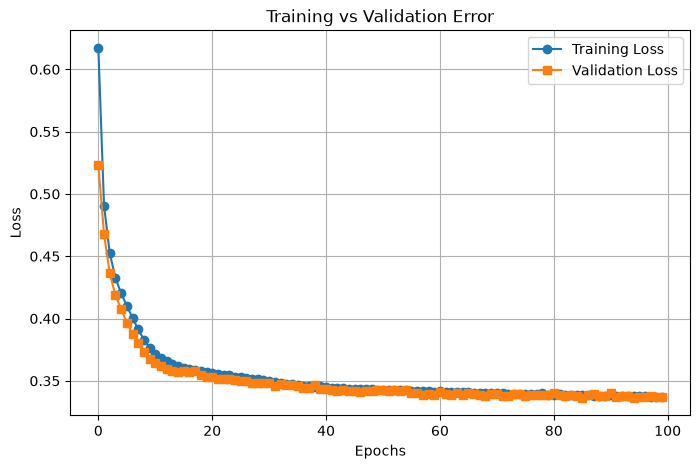

In [37]:
import matplotlib.pyplot as plt
# Plot training vs validation error (loss)
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title("Training vs Validation Error")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

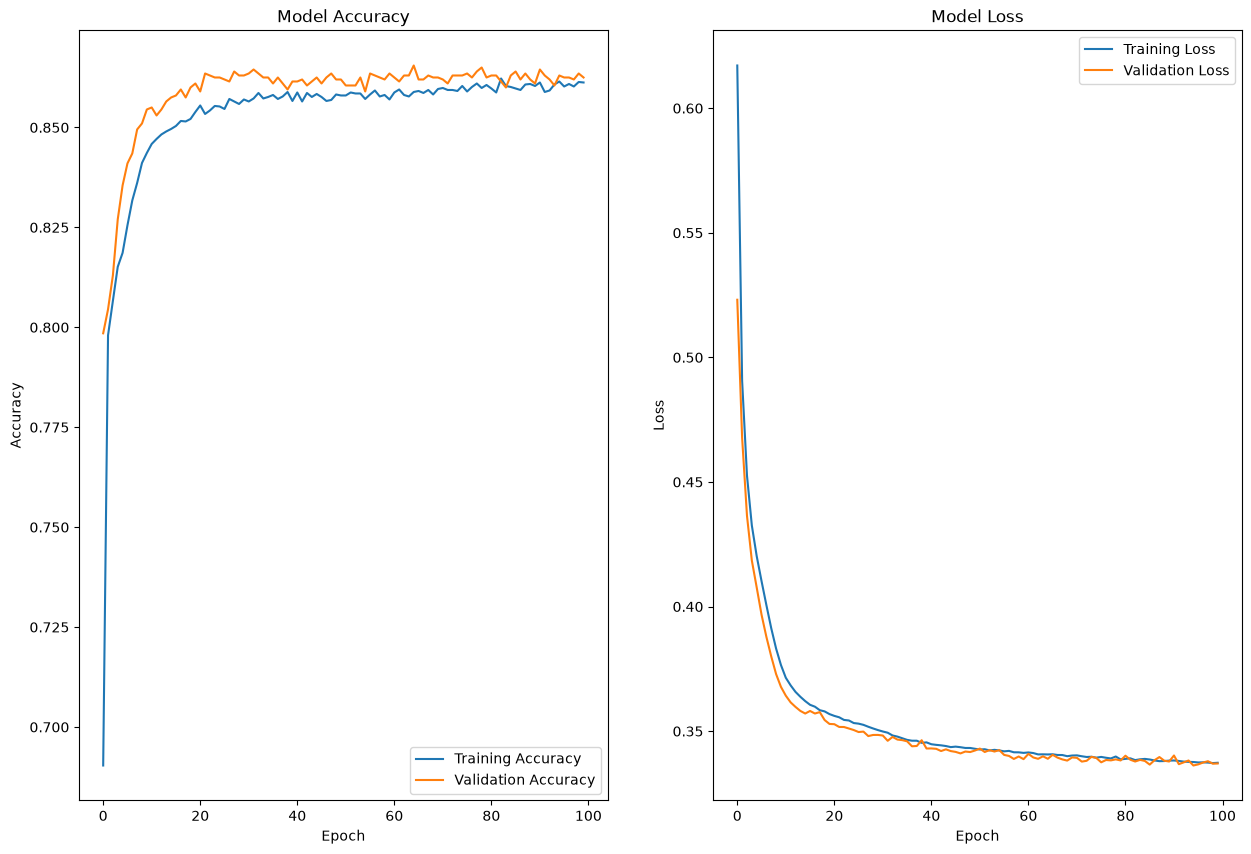

In [38]:
import matplotlib.pyplot as plt
# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
plot_training_history(history)